In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants
rho = 1000     # Density of the fluid (kg/m^3)
CD = 0.0      # Drag coefficient
Gamma = 1   # Circulation constant for simplicity
a = 0.1        # Radius of the vortex core (m)
p_inf = 101325  # Reference pressure (Pa)


In [43]:
def velocity_field(r, theta):
    u_theta = (Gamma / (2 * np.pi)) * (r / a if r < a else 1 / r)
    return np.array([-u_theta * np.sin(theta), u_theta * np.cos(theta)])

def pressure_field(r):
    if r < a:
        return p_inf - (Gamma**2 * rho ) / (4 * np.pi**2 * a**2) + (rho * Gamma**2 * r**2) / (8 * np.pi * a**2) 
    else:
        return p_inf - (Gamma**2 * rho) / (8 * np.pi**2 * r**2) 

# Equations of motion for the microbubble
def microbubble_motion(t, y):
    x, y, vx, vy = y
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Local fluid velocity and pressure
    u = velocity_field(r, theta)
    p_grad = np.array([x, y]) / r * (pressure_field(r + 0.01) - pressure_field(r - 0.01)) / 0.02
    
    # Drag force calculation
    u_diff = u - np.array([vx, vy])
    drag_force = CD * u_diff * np.linalg.norm(u_diff)
    
    # Acceleration components
    ax = 3 / rho * p_grad[0] + 3 / 4 * drag_force[0]
    ay = 3 / rho * p_grad[1] + 3 / 4 * drag_force[1]
    
    return [vx, vy, ax, ay]

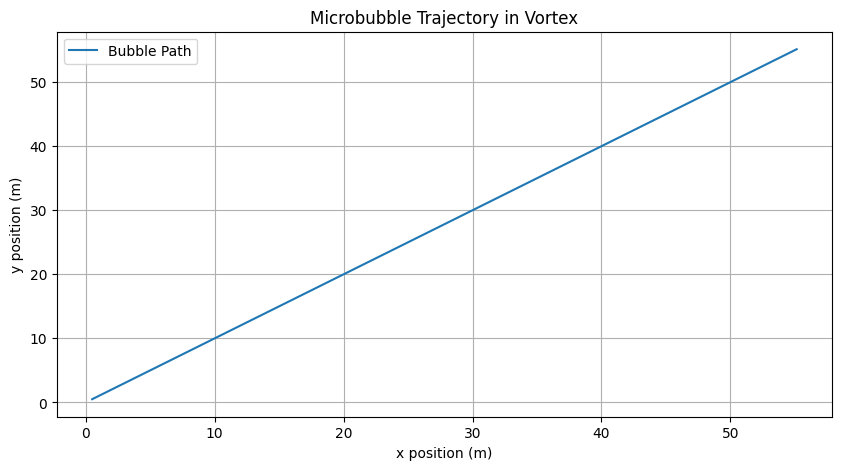

In [44]:
initial_conditions = [0.5, 0.5, 0, 0]  # Starting near the edge of the core

# Time span for the simulation
t_span = (0, 200)  # 10 seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Solve the system of equations
solution = solve_ivp(microbubble_motion, t_span, initial_conditions, t_eval=t_eval, method='RK45')

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(solution.y[0], solution.y[1], label='Bubble Path')
plt.title('Microbubble Trajectory in Vortex')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.grid(True)
plt.legend()
plt.show()




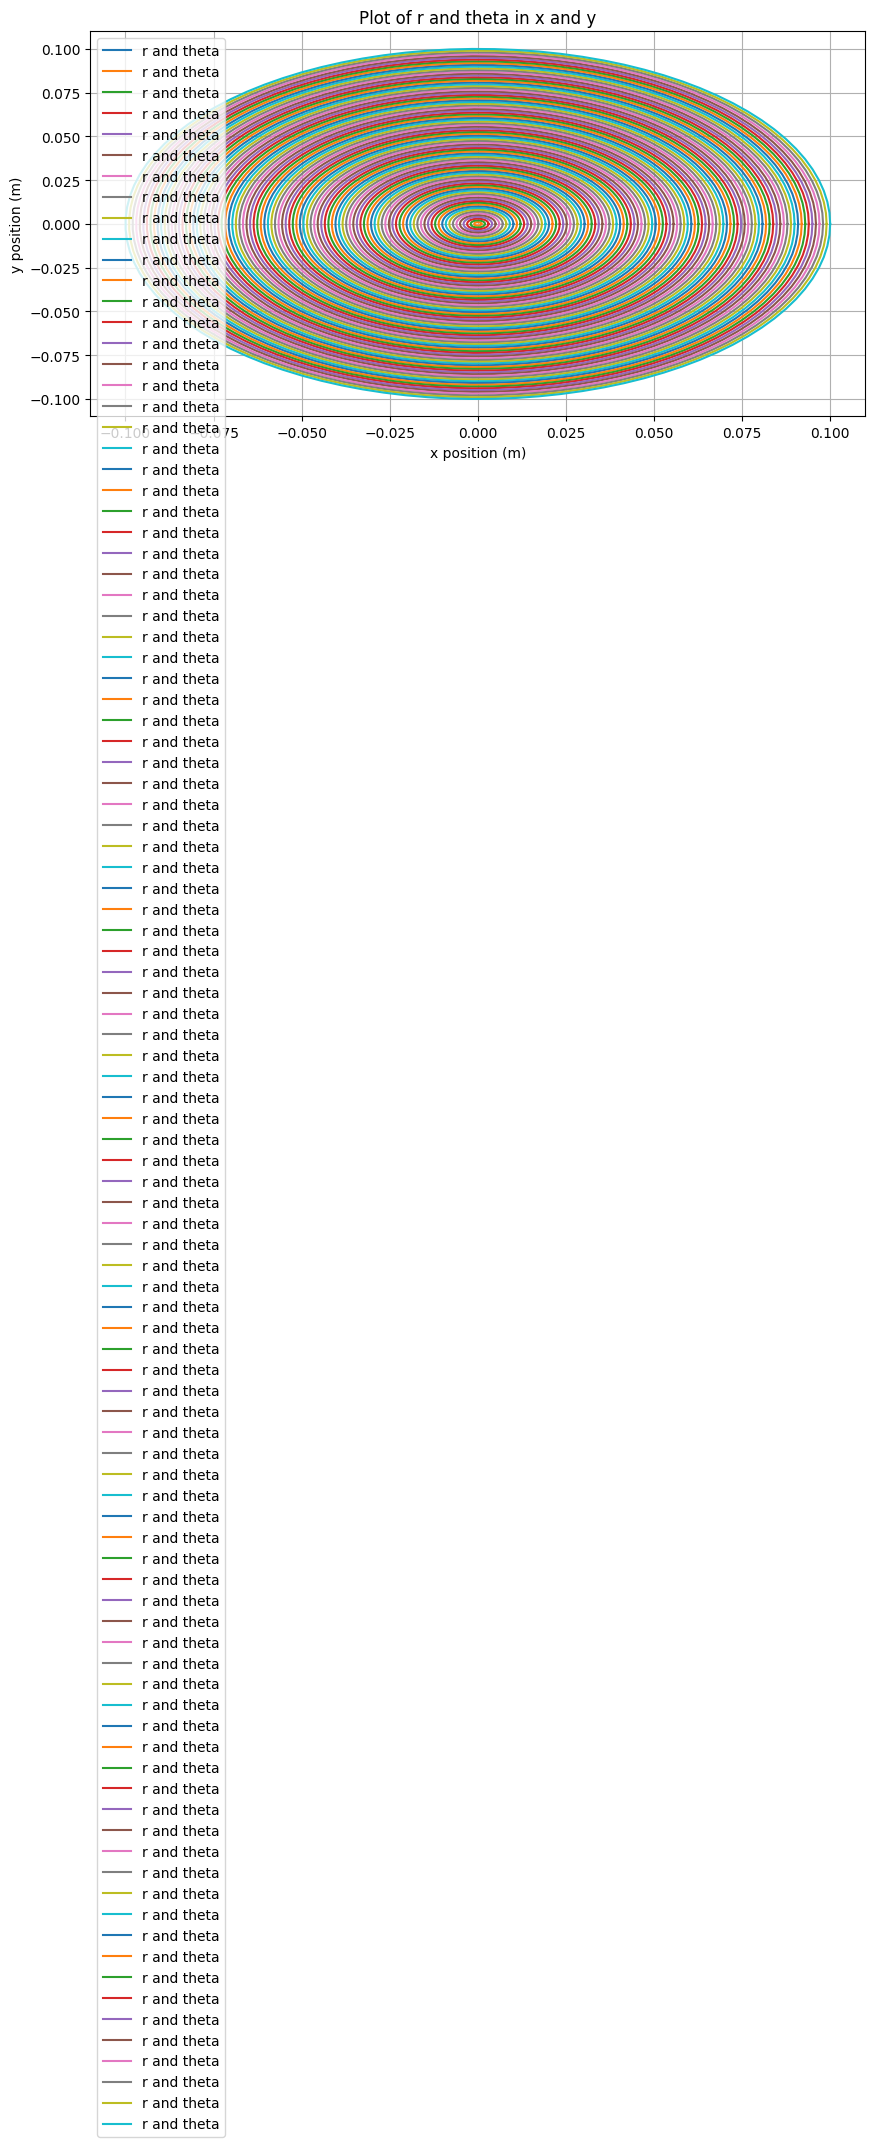

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(R * np.cos(Theta), R * np.sin(Theta), label='r and theta')
plt.title('Plot of r and theta in x and y')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.grid(True)
plt.legend()
plt.show()